In [1]:
import os
import random
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

# FIX RANDOM SEED (để kết quả chạy ổn định)
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Nếu dùng TF >= 2.9
tf.keras.utils.set_random_seed(SEED)

print(f"Đã gắn seed = {SEED}")

# 1. Tải và chuẩn bị Dataset từ CSV
print("--- 1. Loading Local CSV Dataset ---")

max_features = 10000
maxlen = 500
csv_path = 'dataset/IMDB Dataset.csv'

df = pd.read_csv(csv_path)

print(f"Tổng số bản ghi: {len(df)}")

df.head(10)

2026-05-04 20:55:56.760174: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-04 20:55:56.761420: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-04 20:55:56.787609: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-04 20:55:56.788191: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-04 20:55:57.229295: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

Đã gắn seed = 42
--- 1. Loading Local CSV Dataset ---
Tổng số bản ghi: 50000


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
5,"Probably my all-time favorite movie, a story o...",positive
6,I sure would like to see a resurrection of a u...,positive
7,"This show was an amazing, fresh & innovative i...",negative
8,Encouraged by the positive comments about this...,negative
9,If you like original gut wrenching laughter yo...,positive


In [2]:
# Chuyển nhãn về số
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text) # Remove HTML
    text = re.sub(r'[^a-z\s]', '', text) # Remove special chars
    return text

df['review'] = df['review'].apply(clean_text)

df.head(10)

,review,sentiment
0,one of the other reviewers has mentioned that ...,1
1,a wonderful little production the filming tech...,1
2,i thought this was a wonderful way to spend ti...,1
3,basically theres a family where a little boy j...,0
4,petter matteis love in the time of money is a ...,1
5,probably my alltime favorite movie a story of ...,1
6,i sure would like to see a resurrection of a u...,1
7,this show was an amazing fresh innovative ide...,0
8,encouraged by the positive comments about this...,0
9,if you like original gut wrenching laughter yo...,1


In [3]:
# 1.1.1 Xử lý Stop words và Tokenization
import nltk
from nltk.corpus import stopwords
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
stop_words.update(['br', 'movie', 'film'])

print("Đang lọc stop words...")
def remove_stopwords(text):
    return ' '.join([w for w in text.split() if w not in stop_words])

df['review'] = df['review'].apply(remove_stopwords)

print("Đang Tokenizing...")
tokenizer = Tokenizer(num_words=max_features)
tokenizer.fit_on_texts(df['review'])

X = tokenizer.texts_to_sequences(df['review'])
y = df['sentiment'].values

# Chia tập dữ liệu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train sequences: {len(X_train)}")
print(f"Test sequences: {len(X_test)}")

# Cập nhật review_lengths cho các cell sau
review_lengths = [len(x) for x in X_train]

# Để decode được, ta cần reverse_word_index
word_index = tokenizer.word_index
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

Đang lọc stop words...
Đang Tokenizing...
Train sequences: 40000
Test sequences: 10000


In [4]:
# 1.2 Khám phá dữ liệu (Data Exploration)
import numpy as np

# Giải mã một bài đánh giá mẫu
def decode_review(encoded_review):
    return ' '.join([reverse_word_index.get(i, '?') for i in encoded_review if i != 0])

print("Review mẫu:")
print(decode_review(X_train[0]))
print("\nNhãn (1: Tích cực, 0: Tiêu cực):", y_train[0])

# Thống kê độ dài các bài đánh giá
review_lengths = [len(x) for x in X_train]
print(f"\nĐộ dài trung bình: {np.mean(review_lengths):.2f}")
print(f"Độ dài lớn nhất: {np.max(review_lengths)}")
print(f"Độ dài nhỏ nhất: {np.min(review_lengths)}")

Review mẫu:
thats kept asking many fights screaming matches swearing general mayhem minutes comparisons also stand think onedimensional characters little depth virtually impossible care happens badly written director hang beliefs topic done much better dramas tv must confess im really one bad performances must said heroines best friend nasty brother absolutely terrible dont know acting school id apply full post lead role manages impress cast socalled british talent well probably never hear least thats hope next time hire different intriguing thought soundtrack featuring likes snow ian brown im bit music fan im familiar artists output didnt recognise tracks apart run anyone get many many musical montages suppose feel accompanied original images couples kissing lake problem none songs convey mood realise director lacks ability carry emotional journey audience storytelling dialogue ending presumably meant everybody gets least one big shock store remained script given noone root enough tac

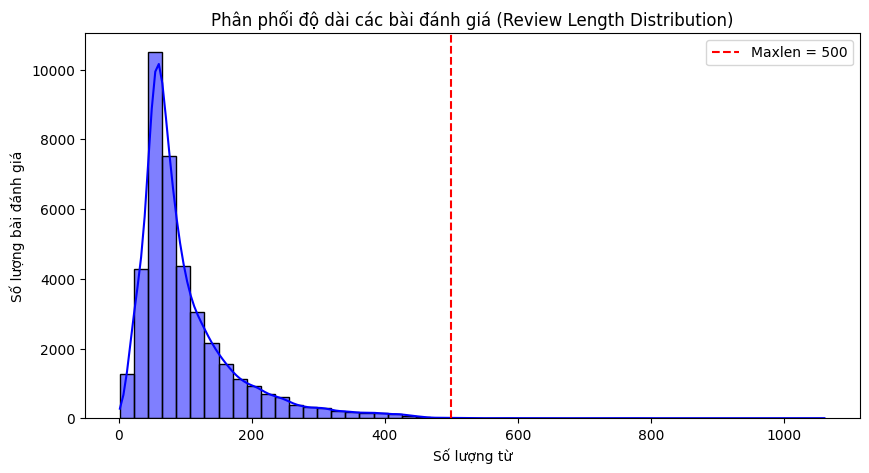

In [5]:
import seaborn as sns
# Visualize phân phối độ dài bài đánh giá
plt.figure(figsize=(10, 5))
sns.histplot(review_lengths, bins=50, kde=True, color='blue')
plt.axvline(maxlen, color='red', linestyle='--', label=f'Maxlen = {maxlen}')
plt.title('Phân phối độ dài các bài đánh giá (Review Length Distribution)')
plt.xlabel('Số lượng từ')
plt.ylabel('Số lượng bài đánh giá')
plt.legend()
plt.show()

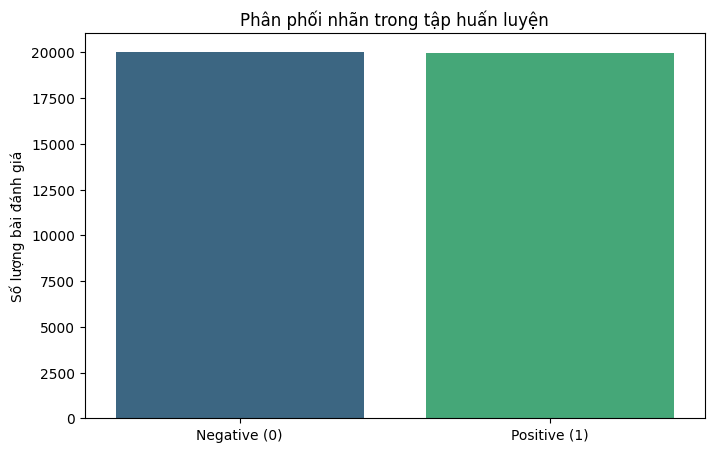

In [6]:
# 1.2 Phân phối nhãn (Sentiment Distribution)
import pandas as pd
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(8, 5))
sns.barplot(x=['Negative (0)', 'Positive (1)'], y=counts, palette='viridis', hue=['Negative (0)', 'Positive (1)'], legend=False)
plt.title('Phân phối nhãn trong tập huấn luyện')
plt.ylabel('Số lượng bài đánh giá')
plt.show()

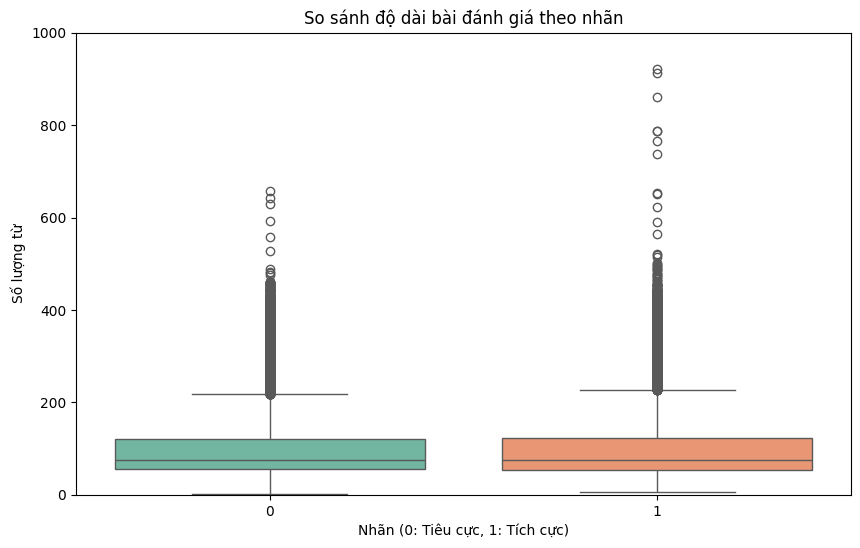

In [ ]:
# 1.3 So sánh độ dài bài đánh giá giữa hai nhãn
df_lengths = pd.DataFrame({'length': review_lengths, 'sentiment': y_train})
plt.figure(figsize=(10, 6))
sns.boxplot(x='sentiment', y='length', data=df_lengths, palette='Set2', hue='sentiment', legend=False)
plt.title('So sánh độ dài bài đánh giá theo nhãn')
plt.xlabel('Nhãn (0: Tiêu cực, 1: Tích cực)')
plt.ylabel('Số lượng từ')
plt.ylim(0, 1000) # Giới hạn 1000 từ để dễ quan sát phần chính
plt.show()

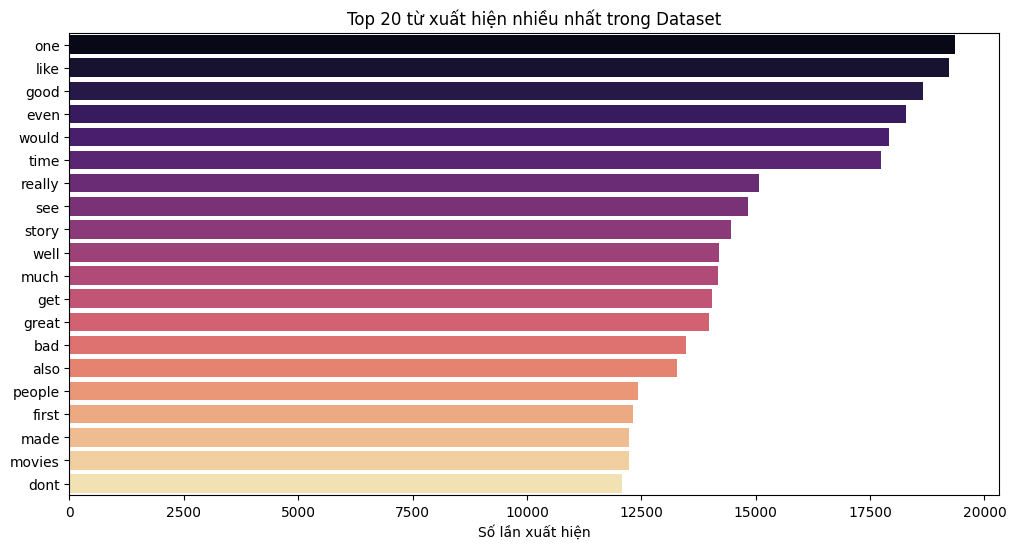

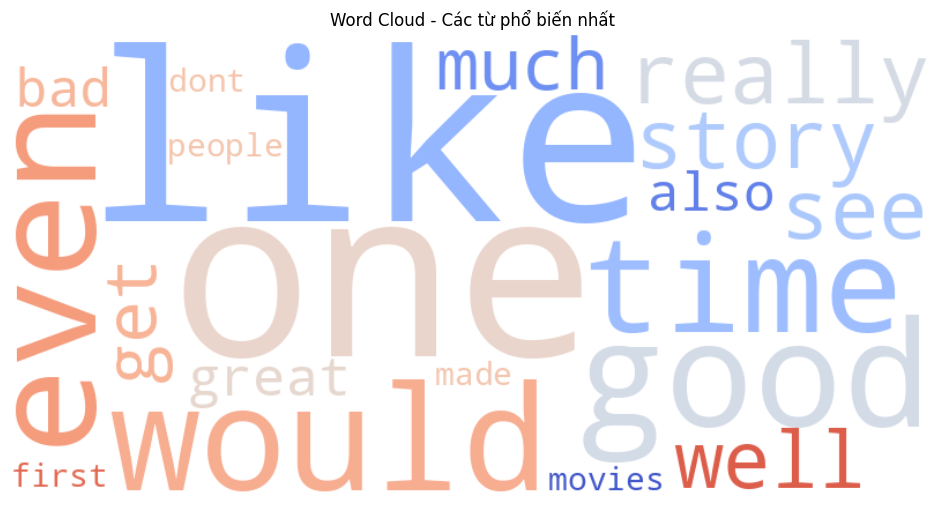

In [8]:
# 1.4 Thống kê các từ xuất hiện nhiều nhất
from collections import Counter
all_words_indices = []
for review in X_train:
    all_words_indices.extend(review)

# Giải mã các chỉ số thành từ (loại bỏ các token đặc biệt 0, 1, 2)
top_words = Counter([reverse_word_index.get(i - 3, '?') for i in all_words_indices if i > 3]).most_common(20)
words, counts = zip(*top_words)

plt.figure(figsize=(12, 6))
sns.barplot(x=list(counts), y=list(words), palette='magma', hue=list(words), legend=False)
plt.title('Top 20 từ xuất hiện nhiều nhất trong Dataset')
plt.xlabel('Số lần xuất hiện')
plt.show()

# 1.5 Word Cloud
try:
    from wordcloud import WordCloud
    word_freq = {word: count for word, count in top_words}
    wc = WordCloud(width=800, height=400, background_color='white', colormap='coolwarm').generate_from_frequencies(word_freq)

    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud - Các từ phổ biến nhất')
    plt.show()
except ImportError:
    print("Thư viện 'wordcloud' chưa được cài đặt. Bạn có thể cài đặt bằng lệnh: pip install wordcloud")

In [9]:
# 2. Tiền xử lý (Padding)
print("\n--- 2. Preprocessing: Padding Sequences ---")
X_train = pad_sequences(X_train, maxlen=maxlen)
X_test = pad_sequences(X_test, maxlen=maxlen)



--- 2. Preprocessing: Padding Sequences ---


In [10]:
# 3. Xây dựng mô hình SimpleRNN (Chống Overfitting)
print("\n--- 3. Building SimpleRNN Model ---")

model = models.Sequential([
    layers.Embedding(max_features, 32, input_length=maxlen),
    # Giữ nguyên SimpleRNN theo yêu cầu chương 3
    # Thêm dropout và recurrent_dropout để hạn chế học vẹt
    layers.SimpleRNN(32, dropout=0.2, recurrent_dropout=0.2),
    layers.Dense(1, activation='sigmoid')
])

# Sử dụng optimizer 'adam' với learning rate mặc định ổn định hơn
model.compile(optimizer='adam', 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

model.summary()



--- 3. Building SimpleRNN Model ---


2026-05-04 20:56:05.046671: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-04 20:56:05.048419: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-04 20:56:05.049583: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 500, 32)           320000    
                                                                 
 simple_rnn (SimpleRNN)      (None, 32)                2080      
                                                                 
 dense (Dense)               (None, 1)                 33        
                                                                 
Total params: 322113 (1.23 MB)
Trainable params: 322113 (1.23 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [11]:
# 4. Huấn luyện (Training) với Early Stopping
import tensorflow as tf # Đảm bảo 'tf' luôn được định nghĩa
print("\n--- 4. Training Model ---")

# Dừng sớm ngay khi val_loss có dấu hiệu tăng (patience=1)
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(X_train, y_train, epochs=15, 
                    batch_size=64, validation_split=0.2,
                    callbacks=[early_stop])



--- 4. Training Model ---
Epoch 1/15
 13/500 [..............................] - ETA: 21s - loss: 0.7195 - accuracy: 0.4952

500/500 [==============================] - 18s 36ms/step - loss: 0.6786 - accuracy: 0.5559 - val_loss: 0.7804 - val_accuracy: 0.5645
Epoch 2/15
500/500 [==============================] - 18s 36ms/step - loss: 0.4564 - accuracy: 0.7957 - val_loss: 0.5865 - val_accuracy: 0.7419
Epoch 3/15
500/500 [==============================] - 17s 35ms/step - loss: 0.3819 - accuracy: 0.8382 - val_loss: 0.6144 - val_accuracy: 0.7436
Epoch 4/15
500/500 [==============================] - 18s 37ms/step - loss: 0.4678 - accuracy: 0.7964 - val_loss: 0.5812 - val_accuracy: 0.6948
Epoch 5/15
500/500 [==============================] - 18s 35ms/step - loss: 0.4010 - accuracy: 0.8273 - val_loss: 0.4192 - val_accuracy: 0.8321
Epoch 6/15
500/500 [==============================] - 18s 35ms/step - loss: 0.3423 - accuracy: 0.8629 - val_loss: 0.5330 - val_accuracy: 0.7663
Epoch 7/15
500/500 [==============================] - 17s 35ms/step - loss: 0.3195 - accuracy: 0.8736 - val_loss: 0.4924 - val_accuracy: 0.8104
Epo

In [12]:
# 5. Đánh giá (Evaluation)
print("\n--- 5. Evaluating Model ---")
results = model.evaluate(X_test, y_test)
print(f"Test Loss: {results[0]:.4f}, Test Accuracy: {results[1]:.4f}")



--- 5. Evaluating Model ---
313/313 [==============================] - 2s 6ms/step - loss: 0.4152 - accuracy: 0.8349
Test Loss: 0.4152, Test Accuracy: 0.8349


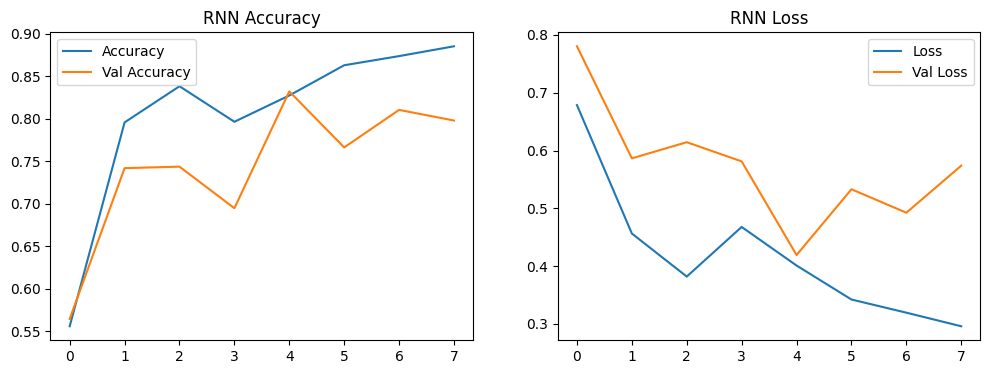

In [13]:
# 6. Visualize kết quả huấn luyện
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('RNN Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('RNN Loss')
plt.legend()
plt.show()


In [14]:
# 7. Dự đoán trên dữ liệu thực tế (Custom Inference)
print("\n--- 7. Testing with custom reviews ---")

def predict_sentiment(text):
    # Tokenize và tiền xử lý text nhập vào bằng tokenizer cục bộ
    review = tokenizer.texts_to_sequences([text])
    review = pad_sequences(review, maxlen=maxlen)
    
    prediction = model.predict(review)
    sentiment = "Positive" if prediction[0][0] > 0.5 else "Negative"
    print(f"Review: '{text}'")
    print(f"Predicted Sentiment: {sentiment} ({prediction[0][0]:.4f})\n")

predict_sentiment("This movie was absolutely amazing and wonderful")
predict_sentiment("It was a waste of time and very boring")



--- 7. Testing with custom reviews ---
1/1 [==============================] - 0s 75ms/step
Review: 'This movie was absolutely amazing and wonderful'
Predicted Sentiment: Positive (0.9751)

1/1 [==============================] - 0s 13ms/step
Review: 'It was a waste of time and very boring'
Predicted Sentiment: Negative (0.1051)



 68/313 [=====>........................] - ETA: 1s

313/313 [==============================] - 2s 6ms/step

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.83      0.83      4961
           1       0.83      0.84      0.84      5039

    accuracy                           0.83     10000
   macro avg       0.84      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000



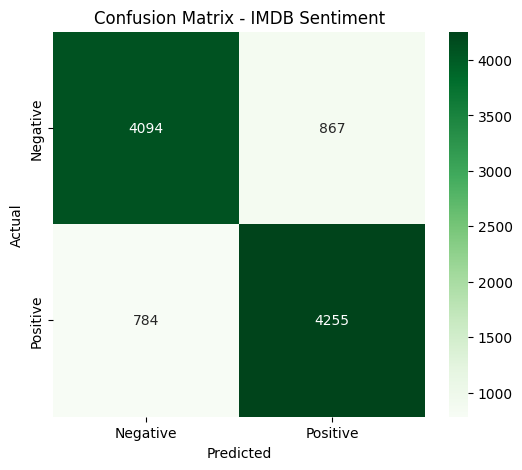

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# 8. Báo cáo phân loại chi tiết
y_pred = (model.predict(X_test) > 0.5).astype("int32")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix - IMDB Sentiment')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

 37/313 [==>...........................] - ETA: 2s

313/313 [==============================] - 2s 7ms/step


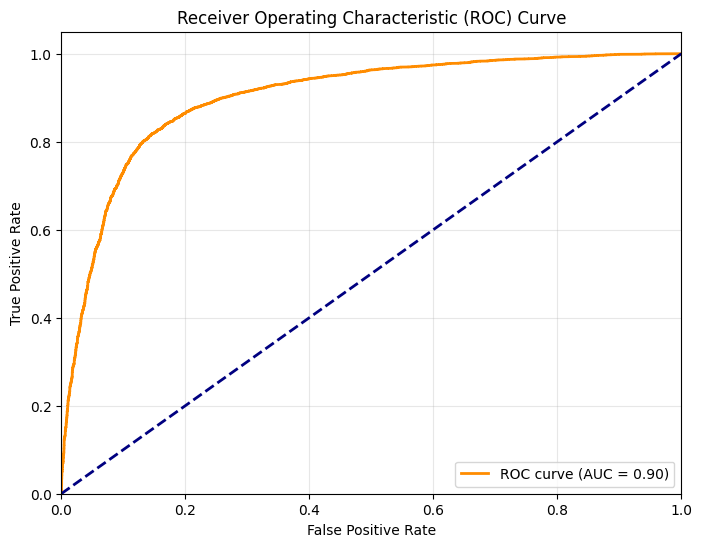

In [16]:
# 9. Đường cong ROC (ROC Curve)
from sklearn.metrics import roc_curve, auc

y_pred_probs = model.predict(X_test).ravel()
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()